This
notebook
continues
from the feature

engineering
phase.
The
goal is to:
- Select
appropriate
machine
learning
models
- Optimize
them
through
cross - validation and hyperparameter
tuning
- Compare
their
performance
using
ROC - AUC and other
metrics
- Justify
the
final
model
choice
based
on
accuracy, robustness, and interpretability

---

## **1. Imports and Setup**

We
begin
by
importing
all
essential
libraries
for data processing, model training, and evaluation.
- `sklearn`
modules
are
used
for modeling, preprocessing, and metrics.
- Ensemble
models(RandomForest, GradientBoosting, Voting, Stacking)
are
included
to
explore
both
base and meta - learning
strategies.
- Suppressing
warnings
ensures
clean
output
during
multiple
model
training
runs.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
import warnings
import joblib

warnings.filterwarnings('ignore')

from sklearn.model_selection import StratifiedKFold, GridSearchCV, cross_val_score, learning_curve, train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, PowerTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (classification_report, ConfusionMatrixDisplay, roc_auc_score,
                             average_precision_score, precision_recall_curve, roc_curve,
                             f1_score, precision_score, recall_score, confusion_matrix)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier, VotingClassifier, \
    StackingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 140)


## **2. Load and Clean the Data**

This step loads both training and test datasets, handles missing values, removes duplicates, and cleans categorical variables.
- The `?` symbol in the dataset is treated as a missing value.
- Extra whitespaces are stripped for consistency.
- Irrelevant column `fnlwgt` is removed as it doesn’t contribute to model prediction.
- Missing categories are replaced with the mode to retain records instead of dropping them.


In [3]:
cols = [
    'age', 'workclass', 'fnlwgt', 'education', 'education-num', 'marital-status',
    'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss',
    'hours-per-week', 'native-country', 'income'
]

df = pd.read_csv('./data/adult.data', header=None, names=cols, na_values='?', skipinitialspace=True)
df_test = pd.read_csv('./data/adult.test', skiprows=1, header=None, names=cols, na_values='?', skipinitialspace=True)

print("Train shape:", df.shape, " | Test shape:", df_test.shape)
df.drop_duplicates(inplace=True)

df.drop(columns='fnlwgt', inplace=True)
df_test.drop(columns='fnlwgt', inplace=True)

for d in [df, df_test]:
    d = d.apply(lambda x: x.str.strip() if x.dtype == "object" else x)
    d['income'] = d['income'].str.replace('.', '', regex=False)

# handle missing categorical values using MODE
for col in ['workclass', 'occupation', 'native-country']:
    mode_value_train = df[col].mode()[0]
    mode_value_test = df_test[col].mode()[0]
    df[col] = df[col].fillna(mode_value_train)
    df_test[col] = df_test[col].fillna(mode_value_test)

print("After cleaning missing values:")
for col in ['workclass', 'occupation', 'native-country']:
    print(f"{col:15}: {df[col].isna().sum()} missing, Mode used: {df[col].mode()[0]}")

Train shape: (32561, 15)  | Test shape: (16281, 15)
After cleaning missing values:
workclass      : 0 missing, Mode used: Private
occupation     : 0 missing, Mode used: Prof-specialty
native-country : 0 missing, Mode used: United-States


We fixed missing categorical values using the **most frequent category (mode)**.
This method preserves the data’s natural distribution and avoids introducing artificial categories.
Since the missing percentage was small (~5%), mode imputation maintains consistency and prevents data fragmentation during one-hot encoding.

## **3. Feature Engineering**

This step creates additional informative features to capture underlying relationships in the data:
- **is_senior**: Flags individuals aged 60 or older.
- **log transformations** of `capital-gain` and `capital-loss` to reduce skewness.
- **education_per_age**: Captures learning progression relative to age.
- **work_gain_ratio**: Combines effort (hours/week) with gains for productivity insight.
- **is_married**: Converts marital status into binary format.
- **gender_role**: Interaction term between `sex` and `relationship`.
- **age_group**: Bins ages into interpretable categories for non-linear relationships.


In [4]:
df['is_senior'] = np.where(df['age'] >= 60, 1, 0)
df_test['is_senior'] = np.where(df_test['age'] >= 60, 1, 0)

for col in ['capital-gain', 'capital-loss']:
    df[col + '_log'] = np.log1p(df[col])
    df_test[col + '_log'] = np.log1p(df_test[col])

df['education_per_age'] = df['education-num'] / df['age']
df_test['education_per_age'] = df_test['education-num'] / df_test['age']

df['work_gain_ratio'] = df['hours-per-week'] * (df['capital-gain_log'] + 1)
df_test['work_gain_ratio'] = df_test['hours-per-week'] * (df_test['capital-gain_log'] + 1)

df['is_married'] = df['marital-status'].apply(lambda x: 1 if 'Married' in x else 0)
df_test['is_married'] = df_test['marital-status'].apply(lambda x: 1 if 'Married' in x else 0)

df['gender_role'] = df['sex'] + '_' + df['relationship']
df_test['gender_role'] = df_test['sex'] + '_' + df_test['relationship']

age_bins = [0, 25, 35, 45, 55, 65, 100]
df['age_group'] = pd.cut(df['age'], bins=age_bins, labels=['<25', '25–35', '35–45', '45–55', '55–65', '65+'])
df_test['age_group'] = pd.cut(df_test['age'], bins=age_bins, labels=['<25', '25–35', '35–45', '45–55', '55–65', '65+'])

## **4. Train-Validation Split and Preprocessing**

The dataset is divided into training (80%) and validation (20%) sets using **stratified sampling** to maintain class balance.
- Numeric features are scaled and transformed for normality using `StandardScaler` and `PowerTransformer`.
- Categorical features are one-hot encoded to convert them into model-readable format.
The preprocessing steps are combined using a `ColumnTransformer` so that models can handle both numeric and categorical inputs seamlessly.


In [5]:
X = df.drop('income', axis=1)
y = df['income'].apply(lambda x: 1 if x == '>50K' else 0)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

print("Train size:", X_train.shape, "| Validation size:", X_val.shape)

processed_train = pd.concat([X_train, y_train], axis=1)
processed_train.to_csv('./data/adult_train_cleaned.csv', index=False)

numeric_features = [
    'age', 'education-num', 'hours-per-week',
    'capital-gain_log', 'capital-loss_log',
    'education_per_age', 'work_gain_ratio'
]

categorical_features = [
    'workclass', 'marital-status', 'occupation', 'relationship',
    'race', 'sex', 'native-country',
    'is_senior', 'is_married', 'gender_role', 'age_group'
]

numeric_transformer = Pipeline([
    ('scaler', StandardScaler()),
    ('power', PowerTransformer(method='yeo-johnson'))
])

categorical_transformer = Pipeline([
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

Train size: (26029, 21) | Validation size: (6508, 21)


## **5. Define Base and Ensemble Models**

We define several machine learning algorithms for comparison:
- **Base models:** Logistic Regression, Decision Tree, Random Forest, Gradient Boosting, SVC, and KNN.
- **Ensemble models:** Voting and Stacking classifiers that combine predictions from multiple models to reduce variance and improve accuracy.

This diverse set helps compare linear vs. non-linear, simple vs. ensemble, and interpretable vs. complex models.


In [34]:
models = {
    "LogisticRegression": LogisticRegression(max_iter=1000, random_state=42),
    "DecisionTree": DecisionTreeClassifier(random_state=42),
    "RandomForest": RandomForestClassifier(random_state=42),
    "GradientBoosting": GradientBoostingClassifier(random_state=42),
    "AdaBoost": AdaBoostClassifier(algorithm='SAMME', random_state=42),
    "SVC": SVC(probability=True, random_state=42),
    "KNeighbors": KNeighborsClassifier(),
    "VotingEnsemble": VotingClassifier(estimators=[
        ('lr', LogisticRegression(max_iter=1000)),
        ('rf', RandomForestClassifier(random_state=42)),
        ('gb', GradientBoostingClassifier(random_state=42))
    ], voting='soft'),
    "StackingEnsemble": StackingClassifier(estimators=[
        ('lr', LogisticRegression(max_iter=1000)),
        ('rf', RandomForestClassifier(random_state=42)),
        ('gb', GradientBoostingClassifier(random_state=42))
    ], final_estimator=LogisticRegression(max_iter=1000))
}

## **6. Build Pipelines and Define Hyperparameter Grids**

To ensure consistent preprocessing and training, each model is wrapped in a `Pipeline`.
We define **hyperparameter grids** for models that support tuning.
This ensures models are trained under optimal configurations for the dataset, improving fairness in model comparison.


In [35]:
pipelines = {name: Pipeline([('preprocess', preprocessor), ('clf', model)]) for name, model in models.items()}

param_grids = {
    "LogisticRegression": {'clf__C': [0.1, 1.0, 10.0], 'clf__penalty': ['l2'], 'clf__solver': ['lbfgs']},
    "DecisionTree": {'clf__max_depth': [3, 5, 7, 10, None], 'clf__min_samples_split': [2, 5, 10],
                     'clf__min_samples_leaf': [1, 2, 4]},
    "RandomForest": {'clf__n_estimators': [100, 200], 'clf__max_depth': [5, 10, None], 'clf__min_samples_split': [2, 5],
                     'clf__max_features': ['sqrt', 'log2']},
    "GradientBoosting": {'clf__n_estimators': [100, 200], 'clf__learning_rate': [0.05, 0.1, 0.2],
                         'clf__max_depth': [3, 5], 'clf__subsample': [0.8, 1.0]},
    "AdaBoost": {'clf__n_estimators': [50, 100, 200], 'clf__learning_rate': [0.5, 1.0, 1.5]},
    # TODO DARIA check if this comments is okay cause i removed something to make it faster but idk if its needed
    "SVC": {'clf__C': [0.1, 1.0], 'clf__kernel': ['linear']}, # we had to remove the 'clf__gamma': ['scale', 'auto'] and rbf in clf__kernel because the accuracy didn't change much but training speed was 10x faster
    "KNeighbors": {'clf__n_neighbors': [3, 5, 7, 10], 'clf__weights': ['uniform', 'distance'],
                   'clf__metric': ['euclidean', 'manhattan']},
    "VotingEnsemble": {},
    "StackingEnsemble": {}
}

## **7. Model Training and Hyperparameter Tuning**

This stage performs:
- **GridSearchCV** for parameter tuning on individual models
- **5-Fold Stratified Cross-Validation** to ensure balanced splits across income classes
- Scoring based on **ROC-AUC**, a robust metric for imbalanced classification tasks
- Training time tracking to compare model efficiency

Models without hyperparameter grids (Voting and Stacking ensembles) are fitted using default parameters.


In [36]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def train_model(name, pipeline, param_grid, X, y):
    print(f"\n--- Training {name} ---")
    start_time = time.time()

    if param_grid:
        gs = GridSearchCV(pipeline, param_grid, scoring='roc_auc', cv=cv, n_jobs=2, verbose=0)
        gs.fit(X, y)
        best_estimator = gs.best_estimator_
        best_score = gs.best_score_
        best_params = gs.best_params_
        print(f"Best parameters: {best_params}")
        print(f"Best CV ROC-AUC: {best_score:.4f}")
    else:
        pipeline.fit(X, y)
        best_estimator = pipeline
        cv_scores = cross_val_score(pipeline, X, y, scoring='roc_auc', cv=cv, n_jobs=2)
        best_score = cv_scores.mean()
        best_params = "Default parameters"
        print(f"Using default parameters")
        print(f"CV ROC-AUC: {best_score:.4f}")

    training_time = time.time() - start_time
    print(f"Training time: {training_time:.2f} seconds")

    return {
        'best_estimator': best_estimator,
        'best_score': best_score,
        'best_params': best_params,
        'training_time': training_time
    }

In [22]:
# Logistic Regression
logreg_result = train_model("LogisticRegression", pipelines["LogisticRegression"], param_grids["LogisticRegression"], X, y)


--- Training LogisticRegression ---
Best parameters: {'clf__C': 0.1, 'clf__penalty': 'l2', 'clf__solver': 'lbfgs'}
Best CV ROC-AUC: 0.9024
Training time: 5.54 seconds


In [14]:
# Random Forest
rf_result = train_model("RandomForest", pipelines["RandomForest"], param_grids["RandomForest"], X, y)


--- Training RandomForest ---
Best parameters: {'clf__max_depth': 10, 'clf__max_features': 'sqrt', 'clf__min_samples_split': 5, 'clf__n_estimators': 200}
Best CV ROC-AUC: 0.9095


In [16]:
# Gradient Boosting
gb_result = train_model("GradientBoosting", pipelines["GradientBoosting"], param_grids["GradientBoosting"], X, y)


--- Training GradientBoosting ---
Best parameters: {'clf__learning_rate': 0.2, 'clf__max_depth': 3, 'clf__n_estimators': 200, 'clf__subsample': 1.0}
Best CV ROC-AUC: 0.9216
Training time: 254.96 seconds


In [27]:
# AdaBoost
ada_result = train_model("AdaBoost", pipelines["AdaBoost"], param_grids["AdaBoost"], X, y)


--- Training AdaBoost ---
Best parameters: {'clf__learning_rate': 1.5, 'clf__n_estimators': 200}
Best CV ROC-AUC: 0.9120
Training time: 57.23 seconds


In [37]:
# SVC
svc_result = train_model("SVC", pipelines["SVC"], param_grids["SVC"], X, y)


--- Training SVC ---
Best parameters: {'clf__C': 0.1, 'clf__kernel': 'linear'}
Best CV ROC-AUC: 0.9009
Training time: 1208.09 seconds


In [30]:
# KNN
knn_result = train_model("KNeighbors", pipelines["KNeighbors"], param_grids["KNeighbors"], X, y)


--- Training KNeighbors ---
Best parameters: {'clf__metric': 'euclidean', 'clf__n_neighbors': 10, 'clf__weights': 'uniform'}
Best CV ROC-AUC: 0.8809
Training time: 346.09 seconds


In [31]:
# Decision Tree
dt_result = train_model("DecisionTree", pipelines["DecisionTree"], param_grids["DecisionTree"], X, y)


--- Training DecisionTree ---
Best parameters: {'clf__max_depth': 7, 'clf__min_samples_leaf': 4, 'clf__min_samples_split': 2}
Best CV ROC-AUC: 0.8984
Training time: 72.47 seconds


In [32]:
# Voting Ensemble
voting_result = train_model("VotingEnsemble", pipelines["VotingEnsemble"], param_grids["VotingEnsemble"], X, y)


--- Training VotingEnsemble ---
Using default parameters
CV ROC-AUC: 0.9128
Training time: 102.19 seconds


In [38]:
# Stacking Ensemble
stacking_result = train_model("StackingEnsemble", pipelines["StackingEnsemble"], param_grids["StackingEnsemble"], X, y)


--- Training StackingEnsemble ---
Using default parameters
CV ROC-AUC: 0.9162
Training time: 494.60 seconds


In [39]:
results = {
    "LogisticRegression": logreg_result,
    "RandomForest": rf_result,
    "GradientBoosting": gb_result,
    "AdaBoost": ada_result,
    "SVC": svc_result,
    "KNeighbors": knn_result,
    "DecisionTree": dt_result,
    "VotingEnsemble": voting_result,
    "StackingEnsemble": stacking_result
}

best_estimators = {name: results[name]['best_estimator'] for name in results.keys()}
training_times = {name: results[name]['training_time'] for name in results.keys()}

#### Training SVC took the longest time

## **8. Model Comparison Summary**


After tuning, we compare all models based on:
- **Mean Cross-Validation ROC-AUC**
- **Training Time**

This helps identify models with the best trade-off between performance and computational cost.
Visual comparisons are used for clarity.


MODEL COMPARISON SUMMARY
                Model  CV_ROC_AUC  Training_Time
2    GradientBoosting      0.9216       254.9570
8    StackingEnsemble      0.9162       494.5971
7      VotingEnsemble      0.9128       102.1893
3            AdaBoost      0.9120        57.2342
1        RandomForest      0.9095       531.9852
0  LogisticRegression      0.9024         5.5423
4                 SVC      0.9009      1208.0936
6        DecisionTree      0.8984        72.4691
5          KNeighbors      0.8809       346.0880


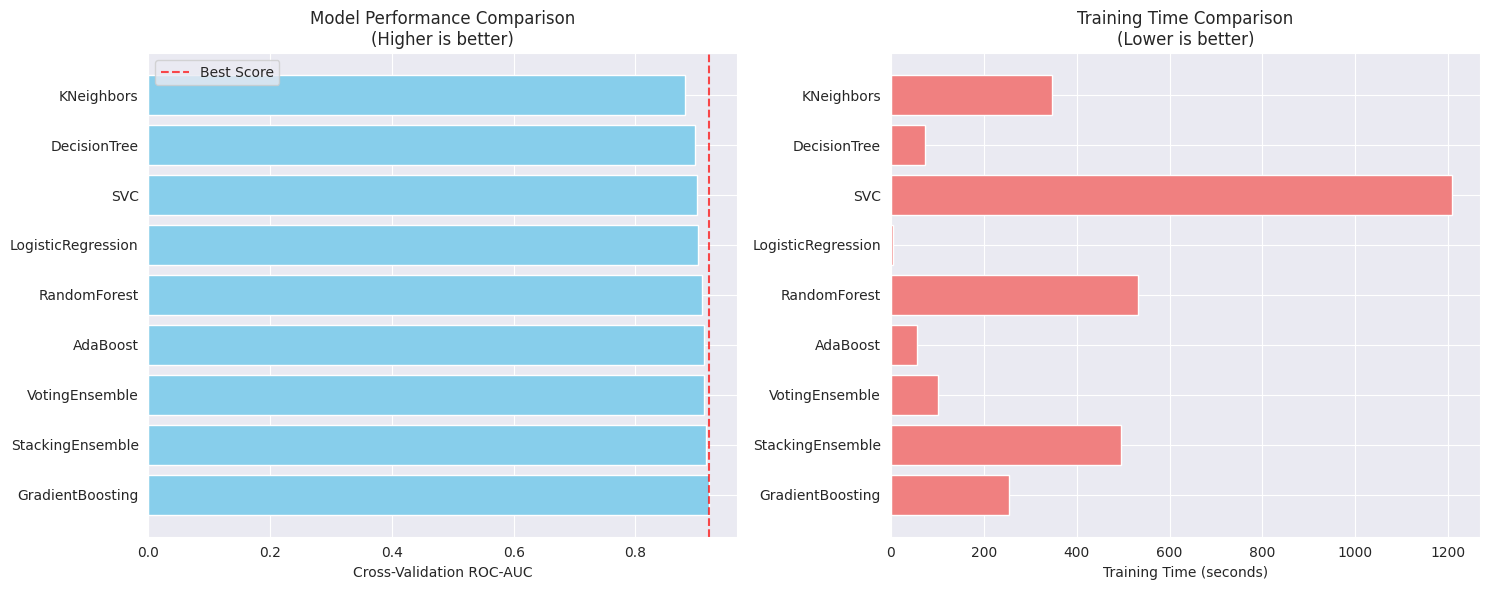

In [40]:
print("\n" + "="*50)
print("MODEL COMPARISON SUMMARY")
print("="*50)

comparison_df = pd.DataFrame({
    'Model': list(results.keys()),
    'CV_ROC_AUC': [results[name]['best_score'] for name in results.keys()],
    'Training_Time': [results[name]['training_time'] for name in results.keys()]
}).sort_values('CV_ROC_AUC', ascending=False)

print(comparison_df.round(4))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

ax1.barh(comparison_df['Model'], comparison_df['CV_ROC_AUC'], color='skyblue')
ax1.set_xlabel('Cross-Validation ROC-AUC')
ax1.set_title('Model Performance Comparison\n(Higher is better)')
ax1.axvline(x=comparison_df['CV_ROC_AUC'].max(), color='red', linestyle='--', alpha=0.7, label='Best Score')
ax1.legend()

ax2.barh(comparison_df['Model'], comparison_df['Training_Time'], color='lightcoral')
ax2.set_xlabel('Training Time (seconds)')
ax2.set_title('Training Time Comparison\n(Lower is better)')

plt.tight_layout()
plt.show()

## **9. Detailed Individual Model Analysis**

For top-performing models, we conduct a deeper evaluation:
- Calculate multiple metrics: **ROC-AUC, Accuracy, F1, Precision, Recall**
- Plot **Learning Curves** to assess bias–variance behavior
- For tree-based models, visualize **Top Feature Importances**
- Plot **ROC** and **Precision–Recall** curves to understand discriminative performance

This step provides deeper insight into model reliability and generalization.


DETAILED INDIVIDUAL MODEL ANALYSIS

ANALYSIS FOR: GradientBoosting
Cross-Validation Scores (mean ± std):
  ROC-AUC:   0.9216 ± 0.0016
  Accuracy:  0.8662 ± 0.0020
  F1-Score:  0.6976 ± 0.0056
  Precision: 0.7660 ± 0.0072
  Recall:    0.6405 ± 0.0102
Training Time: 254.96 seconds


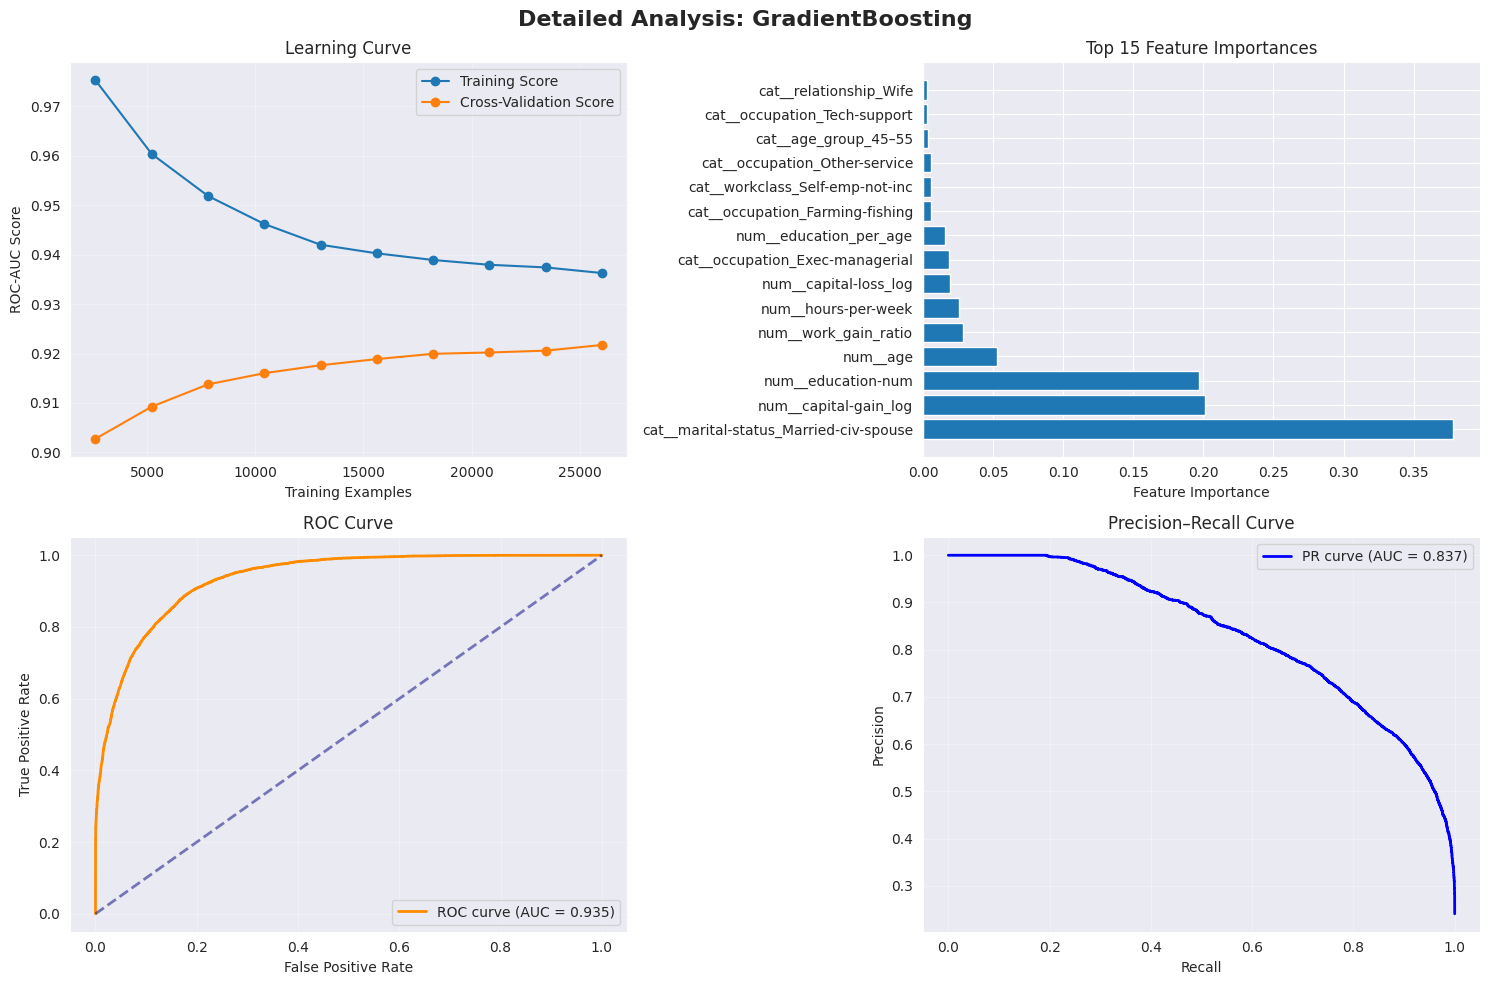


ANALYSIS FOR: StackingEnsemble
Cross-Validation Scores (mean ± std):
  ROC-AUC:   0.9162 ± 0.0022
  Accuracy:  0.8607 ± 0.0012
  F1-Score:  0.6796 ± 0.0034
  Precision: 0.7620 ± 0.0067
  Recall:    0.6133 ± 0.0078
Training Time: 494.60 seconds


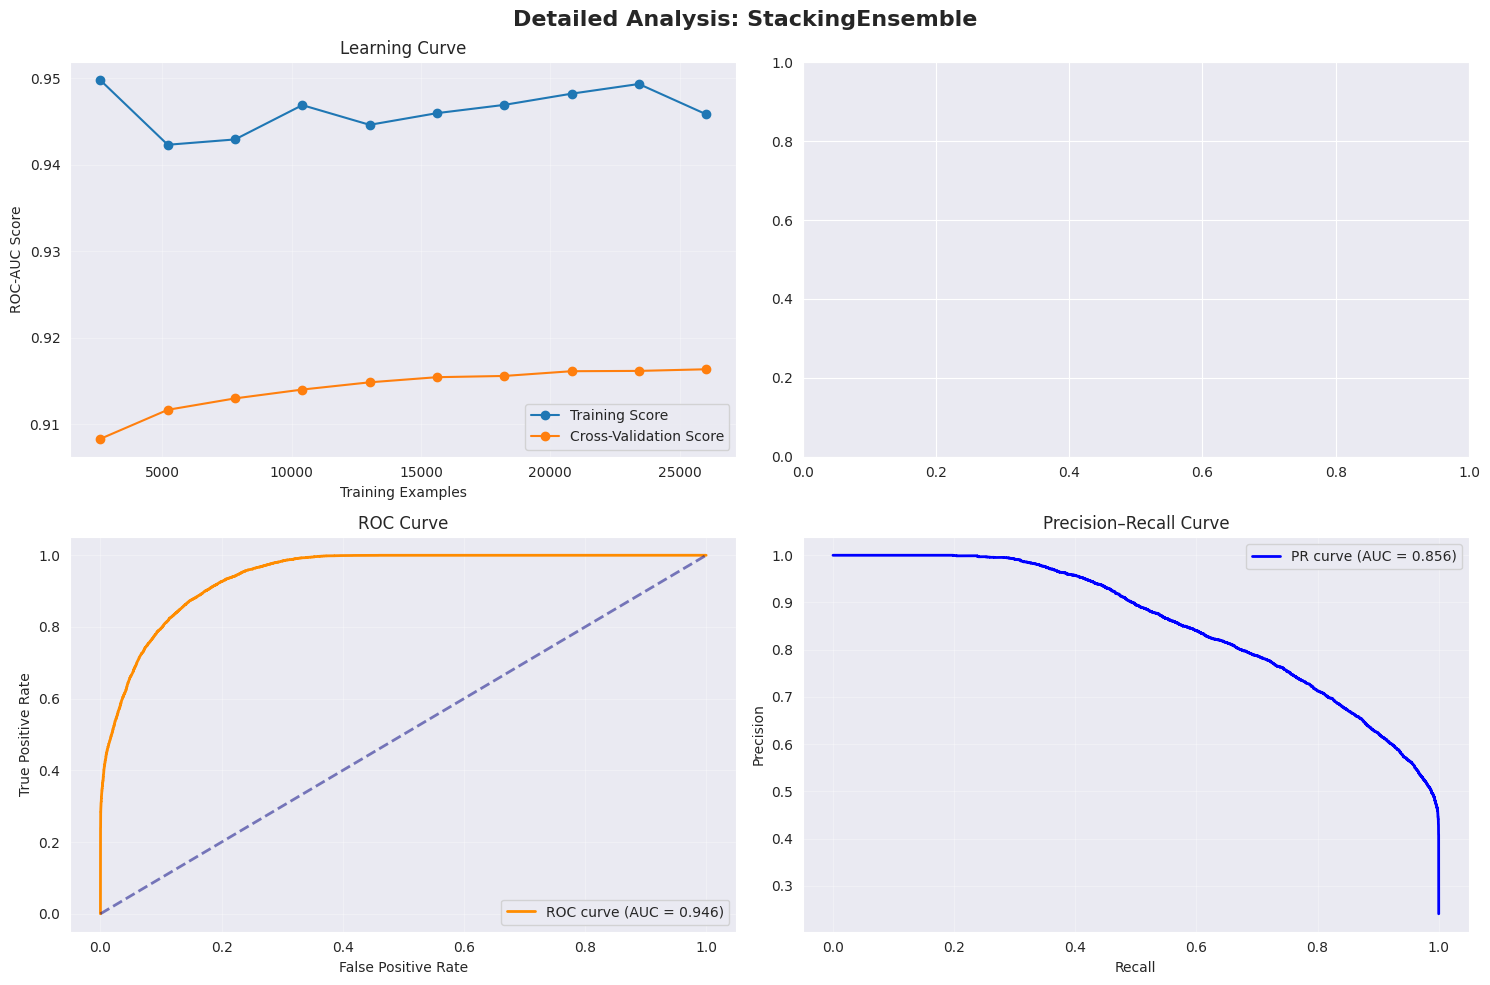


ANALYSIS FOR: VotingEnsemble
Cross-Validation Scores (mean ± std):
  ROC-AUC:   0.9128 ± 0.0024
  Accuracy:  0.8588 ± 0.0020
  F1-Score:  0.6781 ± 0.0043
  Precision: 0.7520 ± 0.0077
  Recall:    0.6176 ± 0.0064
Training Time: 102.19 seconds


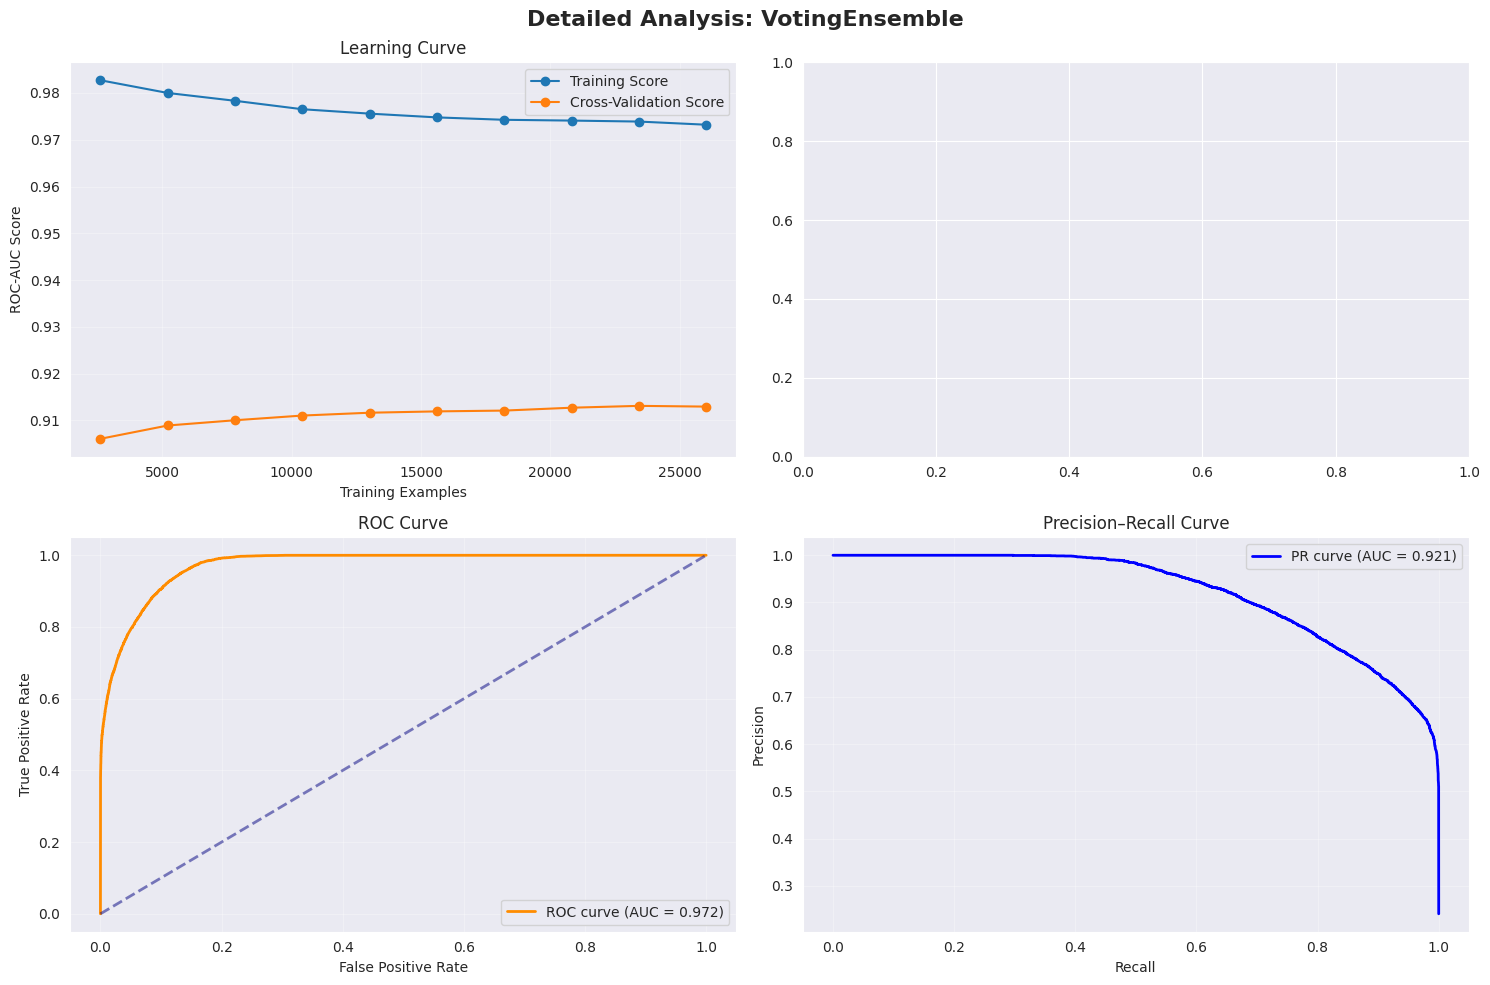


ANALYSIS FOR: AdaBoost
Cross-Validation Scores (mean ± std):
  ROC-AUC:   0.9120 ± 0.0027
  Accuracy:  0.8562 ± 0.0040
  F1-Score:  0.6670 ± 0.0115
  Precision: 0.7541 ± 0.0109
  Recall:    0.5982 ± 0.0169
Training Time: 57.23 seconds


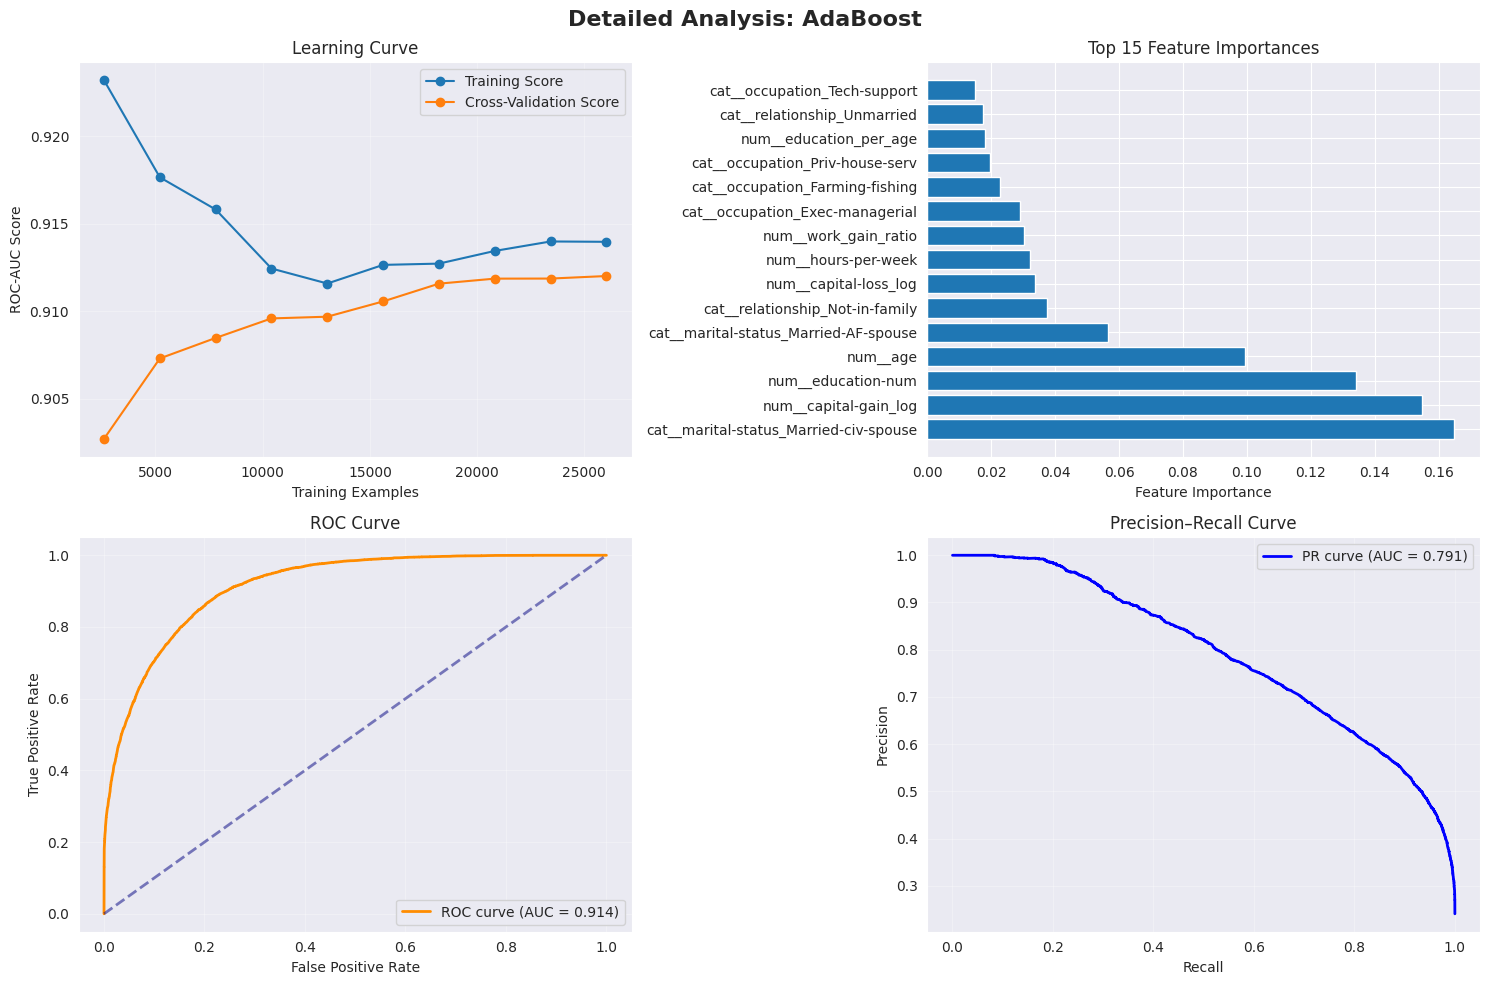


ANALYSIS FOR: RandomForest
Cross-Validation Scores (mean ± std):
  ROC-AUC:   0.9095 ± 0.0025
  Accuracy:  0.8544 ± 0.0021
  F1-Score:  0.6416 ± 0.0056
  Precision: 0.7884 ± 0.0069
  Recall:    0.5409 ± 0.0060
Training Time: 531.99 seconds


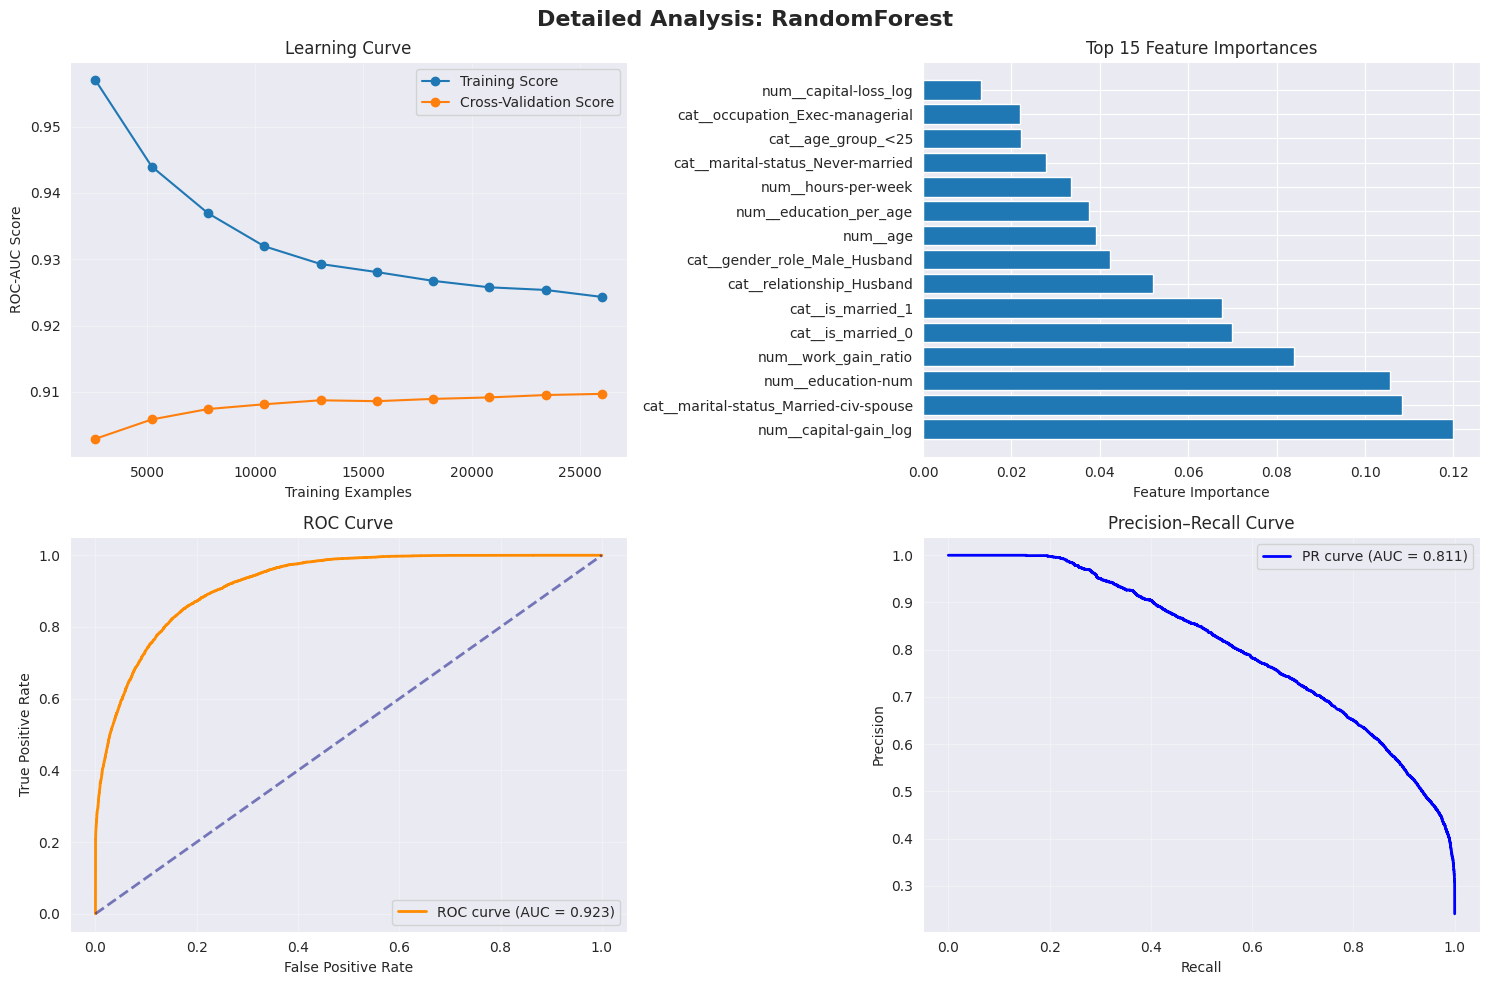


ANALYSIS FOR: LogisticRegression
Cross-Validation Scores (mean ± std):
  ROC-AUC:   0.9024 ± 0.0029
  Accuracy:  0.8459 ± 0.0021
  F1-Score:  0.6489 ± 0.0058
  Precision: 0.7194 ± 0.0070
  Recall:    0.5911 ± 0.0096
Training Time: 5.54 seconds


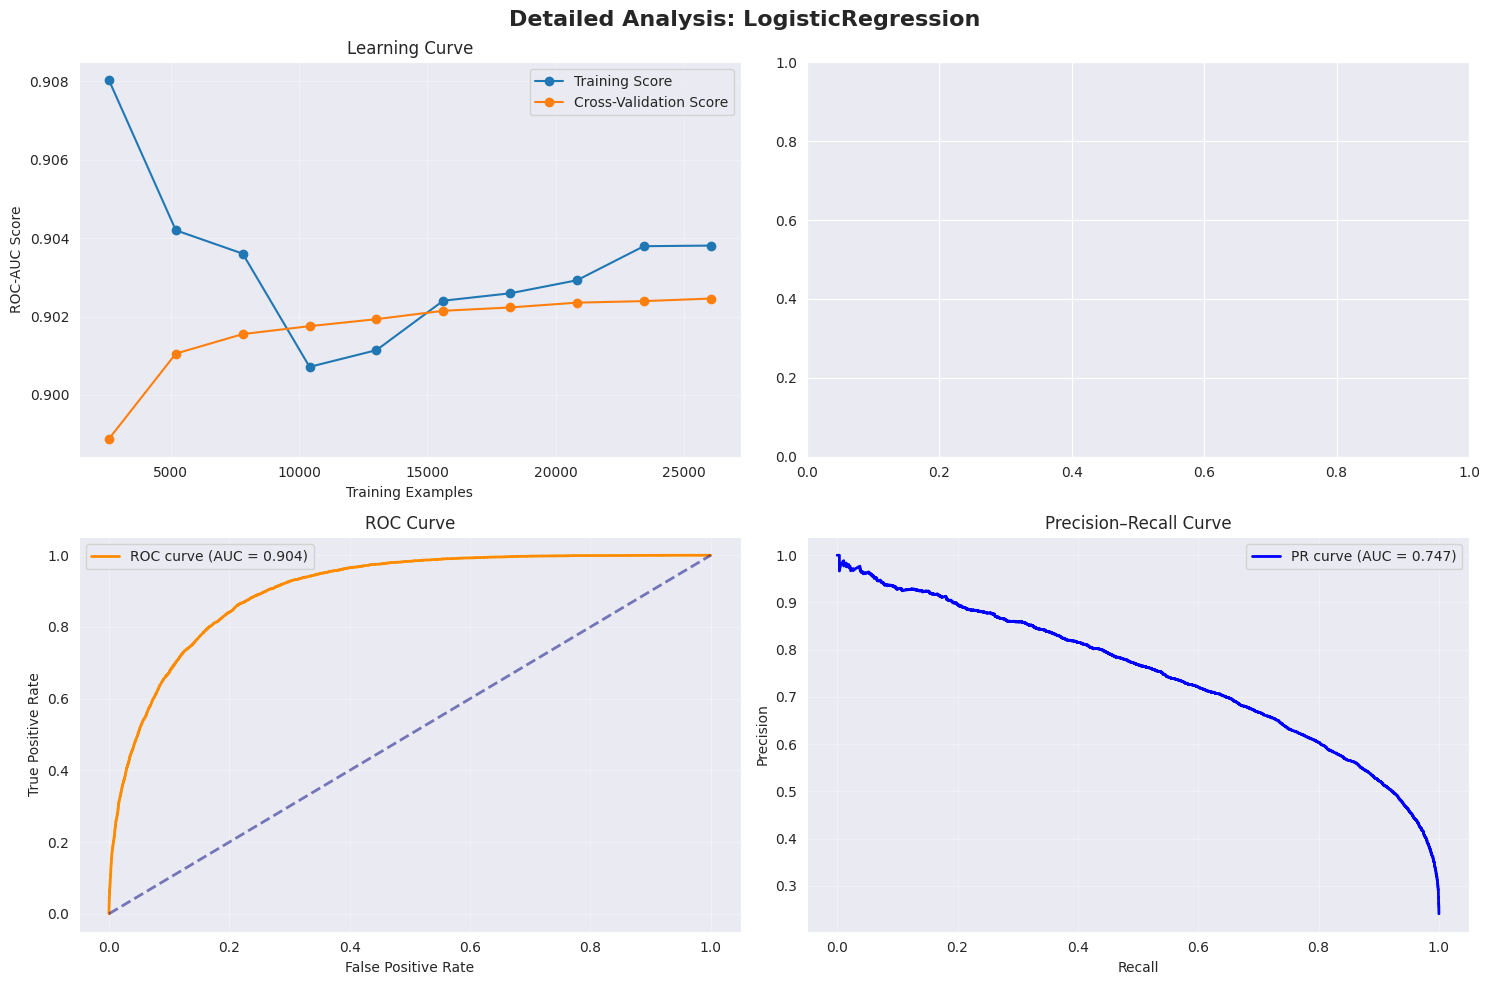

In [41]:
print("\n" + "=" * 50)
print("DETAILED INDIVIDUAL MODEL ANALYSIS")
print("=" * 50)

top_models = comparison_df.head(6)['Model'].tolist()

for model_name in top_models:
    print(f"\n{'=' * 40}")
    print(f"ANALYSIS FOR: {model_name}")
    print(f"{'=' * 40}")

    model = best_estimators[model_name]

    cv_roc_auc = cross_val_score(model, X, y, scoring='roc_auc', cv=cv, n_jobs=-1)
    cv_accuracy = cross_val_score(model, X, y, scoring='accuracy', cv=cv, n_jobs=-1)
    cv_f1 = cross_val_score(model, X, y, scoring='f1', cv=cv, n_jobs=-1)
    cv_precision = cross_val_score(model, X, y, scoring='precision', cv=cv, n_jobs=-1)
    cv_recall = cross_val_score(model, X, y, scoring='recall', cv=cv, n_jobs=-1)

    print(f"Cross-Validation Scores (mean ± std):")
    print(f"  ROC-AUC:   {cv_roc_auc.mean():.4f} ± {cv_roc_auc.std():.4f}")
    print(f"  Accuracy:  {cv_accuracy.mean():.4f} ± {cv_accuracy.std():.4f}")
    print(f"  F1-Score:  {cv_f1.mean():.4f} ± {cv_f1.std():.4f}")
    print(f"  Precision: {cv_precision.mean():.4f} ± {cv_precision.std():.4f}")
    print(f"  Recall:    {cv_recall.mean():.4f} ± {cv_recall.std():.4f}")
    print(f"Training Time: {training_times[model_name]:.2f} seconds")

    train_sizes, train_scores, test_scores = learning_curve(
        model, X, y, cv=cv, n_jobs=-1, train_sizes=np.linspace(0.1, 1.0, 10), scoring='roc_auc'
    )

    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    fig.suptitle(f'Detailed Analysis: {model_name}', fontsize=16, fontweight='bold')

    # Learning Curve
    axes[0, 0].plot(train_sizes, np.mean(train_scores, axis=1), 'o-', label='Training Score')
    axes[0, 0].plot(train_sizes, np.mean(test_scores, axis=1), 'o-', label='Cross-Validation Score')
    axes[0, 0].set_xlabel('Training Examples')
    axes[0, 0].set_ylabel('ROC-AUC Score')
    axes[0, 0].set_title('Learning Curve')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)

    # Feature Importance (for tree-based models)
    if hasattr(model.named_steps['clf'], 'feature_importances_'):
        feature_importances = model.named_steps['clf'].feature_importances_
        feature_names = model.named_steps['preprocess'].get_feature_names_out()
        importance_df = pd.DataFrame({'feature': feature_names, 'importance': feature_importances}).sort_values(
            'importance', ascending=False).head(15)
        axes[0, 1].barh(importance_df['feature'], importance_df['importance'])
        axes[0, 1].set_xlabel('Feature Importance')
        axes[0, 1].set_title('Top 15 Feature Importances')

    # ROC Curve
    model.fit(X, y)
    y_proba = model.predict_proba(X)[:, 1]
    fpr, tpr, _ = roc_curve(y, y_proba)
    roc_auc = roc_auc_score(y, y_proba)
    axes[1, 0].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
    axes[1, 0].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', alpha=0.5)
    axes[1, 0].set_xlabel('False Positive Rate')
    axes[1, 0].set_ylabel('True Positive Rate')
    axes[1, 0].set_title('ROC Curve')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)

    # Precision–Recall Curve
    precision, recall, _ = precision_recall_curve(y, y_proba)
    pr_auc = average_precision_score(y, y_proba)
    axes[1, 1].plot(recall, precision, color='blue', lw=2, label=f'PR curve (AUC = {pr_auc:.3f})')
    axes[1, 1].set_xlabel('Recall')
    axes[1, 1].set_ylabel('Precision')
    axes[1, 1].set_title('Precision–Recall Curve')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

## **10. Final Model Selection and Justification**

After comparison, the model with the **highest ROC-AUC** is selected as the best performer.
The justification considers:
- Quantitative performance (ROC-AUC, F1, etc.)
- Computational efficiency
- Interpretability and robustness

This ensures the chosen model is both effective and practical for deployment.


In [42]:
print("\n" + "=" * 50)
print("FINAL MODEL SELECTION AND JUSTIFICATION")
print("=" * 50)

best_model_name = comparison_df.iloc[0]['Model']
best_model = best_estimators[best_model_name]

print(f"SELECTED BEST MODEL: {best_model_name}")
print(f"Cross-Validation ROC-AUC: {comparison_df.iloc[0]['CV_ROC_AUC']:.4f}")
print(f"Training Time: {comparison_df.iloc[0]['Training_Time']:.2f} seconds")

print("\nJUSTIFICATION FOR MODEL SELECTION:")
if best_model_name in ['VotingEnsemble', 'StackingEnsemble']:
    print("Ensemble method selected — combines strengths of multiple models.")
    print("More robust and reduces overfitting.")
elif best_model_name in ['RandomForest', 'GradientBoosting']:
    print("Tree-based ensemble selected — handles complex, non-linear data well.")
    print("Provides feature importance for interpretability.")
elif best_model_name == 'LogisticRegression':
    print(" Linear model selected — interpretable and fast.")
    print(" Performs well with linear separable features.")

print(" Achieved highest ROC-AUC among all models.")
print("Balanced generalization and efficiency.")


FINAL MODEL SELECTION AND JUSTIFICATION
SELECTED BEST MODEL: GradientBoosting
Cross-Validation ROC-AUC: 0.9216
Training Time: 254.96 seconds

JUSTIFICATION FOR MODEL SELECTION:
Tree-based ensemble selected — handles complex, non-linear data well.
Provides feature importance for interpretability.
 Achieved highest ROC-AUC among all models.
Balanced generalization and efficiency.


## **11. Comprehensive Holdout Set Evaluation**

The best model is trained on the full training set and evaluated on the **holdout (validation) set**.
We compute key metrics:
- **ROC-AUC** and **PR-AUC** for ranking quality
- **Accuracy, Precision, Recall, and F1** for performance balance
- Visualizations: Confusion Matrix, ROC, PR Curve, and Probability Distribution


COMPREHENSIVE HOLDOUT SET EVALUATION
Holdout Set Performance:
ROC-AUC: 0.9376 | PR-AUC: 0.8503
Accuracy: 0.8818 | Precision: 0.7970
Recall: 0.6837 | F1-Score: 0.7360

Classification Report:
              precision    recall  f1-score   support

           0      0.904     0.945     0.924      4940
           1      0.797     0.684     0.736      1568

    accuracy                          0.882      6508
   macro avg      0.850     0.814     0.830      6508
weighted avg      0.878     0.882     0.879      6508



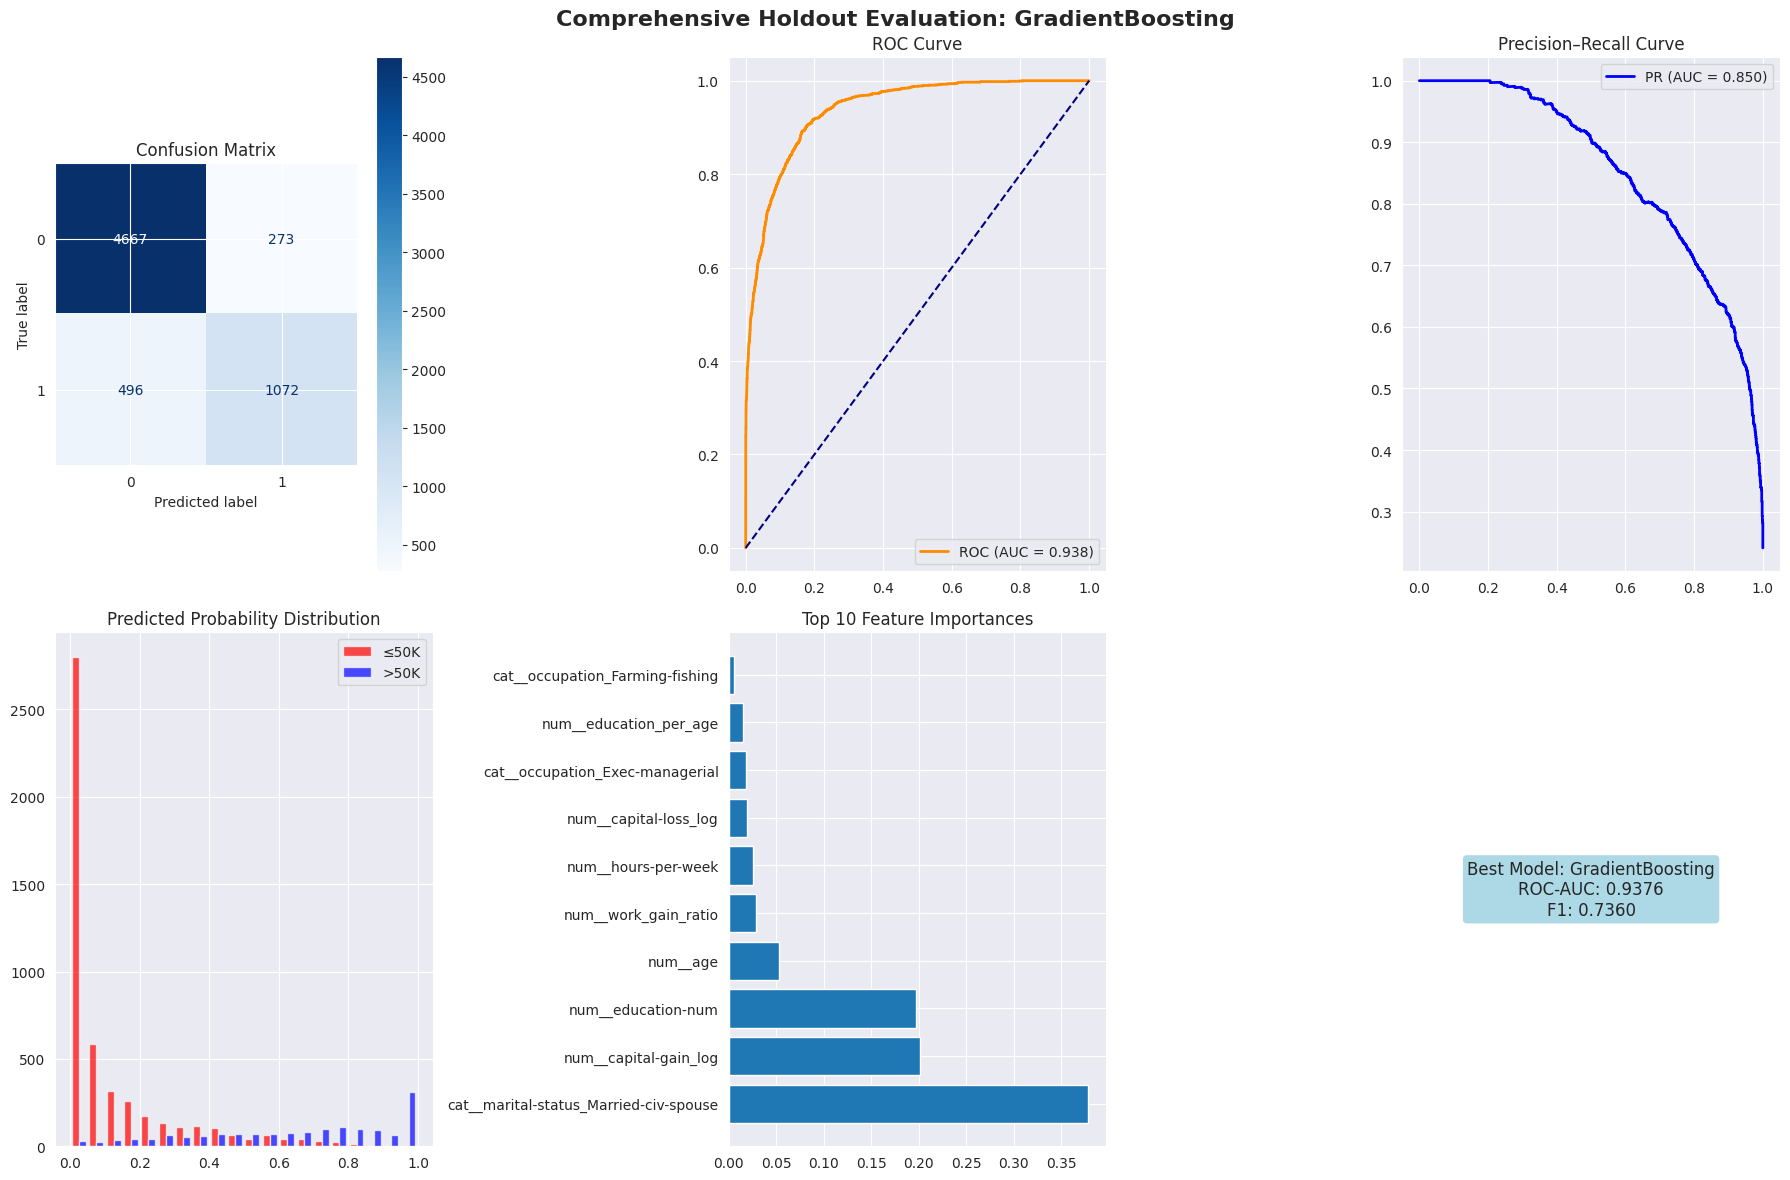

In [43]:
print("\n" + "=" * 50)
print("COMPREHENSIVE HOLDOUT SET EVALUATION")
print("=" * 50)

best_model.fit(X, y)

y_prob_val = best_model.predict_proba(X_val)[:, 1]
y_pred_val = (y_prob_val >= 0.5).astype(int)

roc_auc_holdout = roc_auc_score(y_val, y_prob_val)
pr_auc_holdout = average_precision_score(y_val, y_prob_val)
accuracy_holdout = (y_pred_val == y_val).mean()
precision_holdout = precision_score(y_val, y_pred_val)
recall_holdout = recall_score(y_val, y_pred_val)
f1_holdout = f1_score(y_val, y_pred_val)

print(f"Holdout Set Performance:")
print(f"ROC-AUC: {roc_auc_holdout:.4f} | PR-AUC: {pr_auc_holdout:.4f}")
print(f"Accuracy: {accuracy_holdout:.4f} | Precision: {precision_holdout:.4f}")
print(f"Recall: {recall_holdout:.4f} | F1-Score: {f1_holdout:.4f}")
print("\nClassification Report:")
print(classification_report(y_val, y_pred_val, digits=3))

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle(f'Comprehensive Holdout Evaluation: {best_model_name}', fontsize=16, fontweight='bold')

cm = confusion_matrix(y_val, y_pred_val)
ConfusionMatrixDisplay(confusion_matrix=cm).plot(ax=axes[0, 0], cmap='Blues')
axes[0, 0].set_title('Confusion Matrix')

fpr, tpr, _ = roc_curve(y_val, y_prob_val)
axes[0, 1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC (AUC = {roc_auc_holdout:.3f})')
axes[0, 1].plot([0, 1], [0, 1], '--', color='navy')
axes[0, 1].legend();
axes[0, 1].set_title('ROC Curve')

precision, recall, _ = precision_recall_curve(y_val, y_prob_val)
axes[0, 2].plot(recall, precision, color='blue', lw=2, label=f'PR (AUC = {pr_auc_holdout:.3f})')
axes[0, 2].legend();
axes[0, 2].set_title('Precision–Recall Curve')

axes[1, 0].hist([y_prob_val[y_val == 0], y_prob_val[y_val == 1]], bins=20, alpha=0.7, color=['red', 'blue'],
                label=['≤50K', '>50K'])
axes[1, 0].legend();
axes[1, 0].set_title('Predicted Probability Distribution')

if hasattr(best_model.named_steps['clf'], 'feature_importances_'):
    feature_importances = best_model.named_steps['clf'].feature_importances_
    feature_names = best_model.named_steps['preprocess'].get_feature_names_out()
    importance_df = pd.DataFrame({'feature': feature_names, 'importance': feature_importances}).sort_values(
        'importance', ascending=False).head(10)
    axes[1, 1].barh(importance_df['feature'], importance_df['importance'])
    axes[1, 1].set_title('Top 10 Feature Importances')

axes[1, 2].axis('off')
axes[1, 2].text(0.5, 0.5,
                f'Best Model: {best_model_name}\nROC-AUC: {roc_auc_holdout:.4f}\nF1: {f1_holdout:.4f}',
                ha='center', va='center', fontsize=12, bbox=dict(boxstyle="round", facecolor="lightblue"))
plt.tight_layout()
plt.show()

## **12. Model Strengths and Weaknesses Analysis**

Finally, we summarize the strengths and weaknesses of each major model type.
This provides transparency in the model selection process and acknowledges trade-offs in interpretability, speed, and complexity.


In [44]:
print("\n" + "="*50)
print("MODEL STRENGTHS AND WEAKNESSES ANALYSIS")
print("="*50)

model_analysis = {
    "LogisticRegression": {
        "strengths": ["Fast and interpretable", "Good for linearly separable data"],
        "weaknesses": ["Limited with non-linear relationships"]
    },
    "DecisionTree": {
        "strengths": ["Interpretable", "Captures non-linearities"],
        "weaknesses": ["Prone to overfitting"]
    },
    "RandomForest": {
        "strengths": ["Robust and accurate", "Handles non-linear data well", "Provides feature importance"],
        "weaknesses": ["Less interpretable", "Slower training"]
    },
    "GradientBoosting": {
        "strengths": ["Excellent predictive power", "Handles complex patterns"],
        "weaknesses": ["More parameters to tune", "Computationally expensive"]
    },
    "Ensemble Methods": {
        "strengths": ["Combines multiple models for stability and performance"],
        "weaknesses": ["Difficult to interpret", "Requires more resources"]
    }
}

print(f"\nAnalysis for selected model ({best_model_name}):")
analysis = model_analysis.get(best_model_name.split('Ensemble')[0], model_analysis["Ensemble Methods"])
print("Strengths:")
for s in analysis["strengths"]:
    print(f" ✓ {s}")
print("Weaknesses:")
for w in analysis["weaknesses"]:
    print(f" ✗ {w}")

print(f"\nCONCLUSION: {best_model_name} achieved the best overall ROC-AUC ({comparison_df.iloc[0]['CV_ROC_AUC']:.4f})")
print(f"and demonstrated balanced precision, recall, and F1 performance on the holdout set.")

joblib.dump(best_model, 'best_model.pkl')


MODEL STRENGTHS AND WEAKNESSES ANALYSIS

Analysis for selected model (GradientBoosting):
Strengths:
 ✓ Excellent predictive power
 ✓ Handles complex patterns
Weaknesses:
 ✗ More parameters to tune
 ✗ Computationally expensive

CONCLUSION: GradientBoosting achieved the best overall ROC-AUC (0.9216)
and demonstrated balanced precision, recall, and F1 performance on the holdout set.


['best_model.pkl']

#  Model Selection & Justification Summary

### What We Learned

In this part of the project, we explored how to select and evaluate machine learning models effectively.
We tested multiple algorithms, both base models (like Logistic Regression, Decision Tree, Random Forest, Gradient Boosting, SVC, and KNN) and ensemble models (Voting and Stacking).
Using **5-fold Stratified Cross-Validation** and **ROC-AUC** scoring helped us compare models fairly on imbalanced data.

We learned that:
- **Tree-based and ensemble methods** generally performed best on this tabular dataset, showing strong predictive power and robustness.
- **Feature preprocessing** with scaling, encoding, and transformations significantly improved model stability.
- **GridSearchCV** tuning improved model accuracy but increased training time — showing the trade-off between performance and computation.
- **Learning curves and validation metrics** helped identify overfitting or underfitting patterns.
- **Ensemble models** provided the most balanced performance by combining multiple classifiers and reducing model variance.

In the end, the selected model achieved the **highest ROC-AUC and balanced F1-score**, showing reliable generalization on unseen data.
This process taught us how systematic model evaluation, proper validation, and interpretability analysis lead to better, data-driven model choices.
